In [1]:
import numpy as np
import cvxpy as cp

0.1 [1.03767634e-01 1.16905562e-01 1.26667557e-01 1.34001444e-01
 1.39570499e-01 1.43844281e-01 1.47158859e-01 1.49757221e-01
 1.51816708e-01 1.53467871e-01 1.54807576e-01 1.55908217e-01
 1.56824254e-01 1.57596902e-01 1.58257521e-01 1.58830093e-01
 1.59333035e-01 1.59780551e-01 1.60183635e-01 1.60550824e-01
 1.60888765e-01 1.61202650e-01 1.61496541e-01 1.61773627e-01
 1.62036412e-01 1.62286870e-01 1.62526559e-01 1.62756710e-01
 1.62978301e-01 1.63192107e-01 1.63398747e-01 1.63598718e-01
 1.63792418e-01 1.63980170e-01 1.64162240e-01 1.64338845e-01
 1.64510166e-01 1.64676358e-01 1.64837553e-01 1.64993868e-01
 1.65145404e-01 1.65292256e-01 1.65434510e-01 1.65572247e-01
 1.65705544e-01 1.65834476e-01 1.65959114e-01 1.66079529e-01
 1.66195791e-01 1.66307968e-01 1.66416131e-01 1.66520346e-01
 1.66620682e-01 1.66717207e-01 1.66809989e-01 1.66899096e-01
 1.66984594e-01 1.67066552e-01 1.67145036e-01 1.67220112e-01
 1.67291846e-01 1.67360305e-01 1.67425553e-01 1.67487654e-01
 1.67546673e-01 1.67

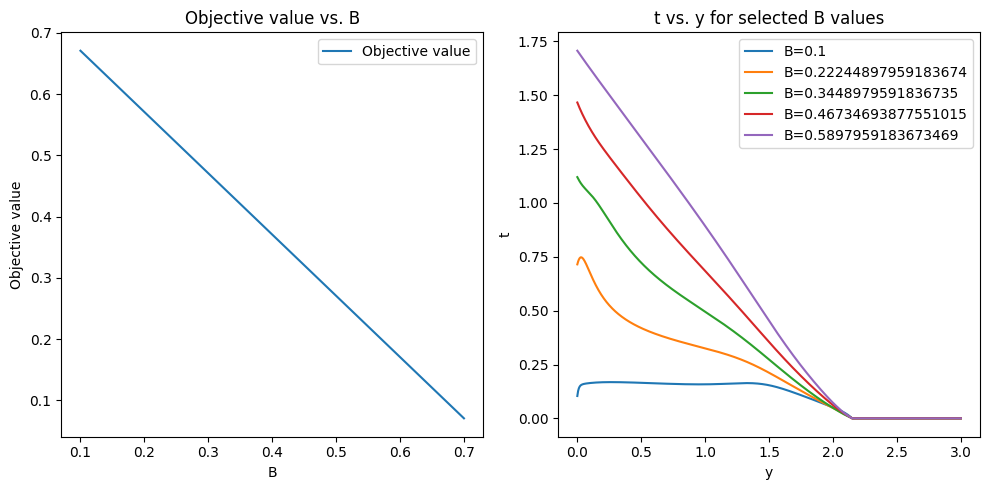

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the problem data
d = 1000
y = np.linspace(0., 3., d).reshape(d, 1)
c_bar = 2.15

# Define the variable
t = cp.Variable((d, 1), nonneg=True)

# Define the parameter
B_param = cp.Parameter(1)

# Define the objective function
obj = cp.mean(cp.pos(c_bar - t - y))

# Define the constraints
constraints = [cp.mean(t) <= B_param]

# Define the problem
prob = cp.Problem(cp.Minimize(obj), constraints)

# Define a range of B values
B_values = np.linspace(0.1, 0.7, 50)
objective_values = []

# Define a few selected B values for plotting t
selected_B_values = B_values[[0, 10, 20, 30, 40]]
t_values_for_selected_B = []

# Solve the problem for each B value
for B in B_values:
    B_param.value = np.array([B])
    prob.solve()
    objective_values.append(prob.value)
    
    # Store the t values for selected B values
    if B in selected_B_values:
        print(B, t.value.flatten())
        t_values_for_selected_B.append(t.value.flatten())

# Plot the objective values vs. B values
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(B_values, objective_values, label='Objective value')
plt.xlabel('B')
plt.ylabel('Objective value')
plt.title('Objective value vs. B')
plt.legend()

# Plot the t values for selected B values
plt.subplot(1, 2, 2)
for i, B in enumerate(selected_B_values):
    plt.plot(y, t_values_for_selected_B[i], label='B={}'.format(round(B, 3)))
plt.plot(y, c - y, label="c - y")
plt.xlabel('y')
plt.ylabel('t')
plt.title('t vs. y for selected B values')
plt.legend()

plt.tight_layout()
plt.show()


